### Libraries and Functions

In [1]:
import pandas as pd
import numpy as np
import pickle

from tqdm import tqdm
from sympy import Basic, parse_expr
from joblib import Parallel, delayed
from matplotlib.patches import Patch
from func_timeout import func_timeout, FunctionTimedOut

from symbolic_regression.utils.visualization import plot_results
from symbolic_regression.utils.model_utils import tree_size

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
def get_final_expr(
    dataset_equations: dict[str, list],
    method: str,
    run_idx: int
) -> Basic:
    """
    Extracts the final SymPy expression for a given method and run.

    For the 'RFGPCMI' method, it returns the sum of the final sub-expressions. 
    For all other methods, it returns the single final expression.

    Parameters
    ----------
    dataset_equations : dict[str, list]
        A dictionary containing the equations for a dataset, keyed by method name.
    method : str
        The name of the symbolic regression method (e.g., 'GP', 'RFGPCMI').
    run_idx : int
        The index of the execution run to extract the expression from.

    Returns
    -------
    Basic
        The final SymPy expression.
    """

    if method != "RFGPCMI":
        return dataset_equations [method][run_idx][-1].sympy_format
    
    else:
        return sum(
            sub_expr[-1].sympy_format 
            for sub_expr in dataset_equations [method][run_idx]
        ) # type: ignore
    
def safe_simplify_timeout(
    expr: Basic, 
    timeout_seconds: int = 5
):
    """
    Attempts to simplify a SymPy expression within a specified time limit.

    This function uses `func_timeout` to prevent the `simplify` method 
    from running indefinitely. If the simplification takes longer than 
    the given timeout, the original, unsimplified expression is returned.
    Any other exceptions raised during simplification are propagated naturally.

    Parameters
    ----------
    expr : sympy.core.basic.Basic
        The SymPy mathematical expression to be simplified.
    timeout_seconds : int or float, optional
        The maximum number of seconds to allow the simplification process 
        to run. Default is 5.

    Returns
    -------
    sympy.core.basic.Basic
        The simplified SymPy expression if successful and within the time 
        limit; otherwise, the original `expr`.
    """

    try: 
        return func_timeout(timeout_seconds, expr.simplify)
    except FunctionTimedOut:
        return expr

### Data Preprocessing

In [3]:
# Define the true equations as strings for each dataset
true_equations_str = {
    "F1": "-6.67408e-11 * (X1 * X2) / X3**2",
    "F2": "30 * X1 * X3 / ((X1 - 10) * X2**2)",
    "Friedman1": "10 * sin(pi * X1 * X2) + 20 * (X3 - 0.5)**2 + 10 * X4 + 5 * X5",
    "Friedman2": "sqrt( X1**2 + (X2 * X3 - 1 / (X2 * X4))**2 )",
    "Friedman3": "atan((X2 * X3 - 1 / (X2 * X4)) / X1)"
}

In [4]:
# Load synthetic dataset results
with open('data_synthetic.pkl', "rb") as f:
    synth = pickle.load(f)['kwargs']

results_df, features = synth['df'], synth['features'],
equations, execution_times = synth['equations'], synth['execution_times']

# Calculate the number dataframe index runs level
num_runs = results_df.index.get_level_values('run').nunique()

# Reorder MultiIndex columns for consistent plotting
order = {
    'dataset': ['F1', 'F2', 'Friedman1', 'Friedman2', 'Friedman3'],
    'method':  ['GPPI', 'GPSHAP', 'GPCMI', 'RFGPCMI', 'GP'],
    'metric':  ['training_losses', 'validation_losses', 'test_losses']
}

for level, cols in order.items():
    results_df = results_df.reindex(columns=cols, level=level)

results_df.tail(3)

dataset                F1                                                \
method               GPPI                                        GPSHAP   
metric    training_losses validation_losses test_losses training_losses   
run epoch                                                                 
99  90           0.000013          0.000015    0.000016        0.001393   
    95           0.000011          0.000020    0.000016        0.001381   
    100          0.000012          0.000019    0.000016        0.001162   

dataset                                                                    \
method                                            GPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.001232    0.001426        0.000065          0.000120   
    95             0.001246    0.001426        0.000098          0.000077   
    100            0.001298    0.001426        0.000098          0.000078   

dataset                                ...   Friedman3                  \
method                        RFGPCMI  ...      GPSHAP           GPCMI   
metric    test_losses training_losses  ... test_losses training_losses   
run epoch                              ...                               
99  90       0.000096        0.001235  ...    0.138991        0.020390   
    95       0.000096        0.001235  ...    0.130249        0.019387   
    100      0.000096        0.000999  ...    0.137249        0.020523   

dataset                                                                    \
method                                          RFGPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  90             0.021808    0.019504        0.020201          0.020843   
    95             0.022817    0.019504        0.020201          0.020843   
    100            0.021090    0.019504        0.020201          0.020843   

dataset                                                              
method                             GP                                
metric    test_losses training_losses validation_losses test_losses  
run epoch                                                            
99  90       0.019477        0.020154          0.020554    0.019504  
    95       0.019477        0.020462          0.020095    0.019504  
    100      0.019477        0.020593          0.019811    0.019504  

[3 rows x 75 columns]

### Predictive Performance

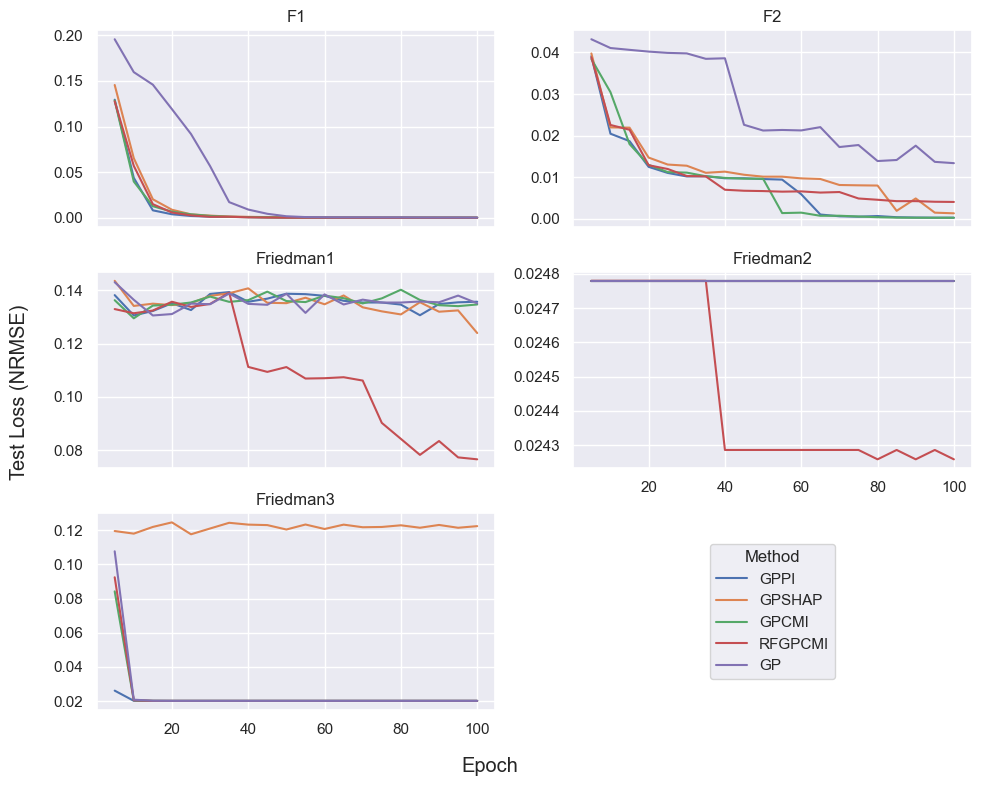

In [5]:
# Plotting test losses for each dataset and method per epoch
fig, axes = plot_results(
    results_df.groupby(level='epoch').median(), 
    nrows=3, 
    ncols=2,
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric",
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.lineplot(data=data, ax=ax, dashes=None)
)

# Set X and Y label for the entire figure
fig.supxlabel("Epoch", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[4].set_xlabel("") # Hide the x-label

# Remove legends from individual subplots
for ax in axes[:5]: ax.get_legend().remove()

# Take the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center',
    title="Method"
)
plt.show()

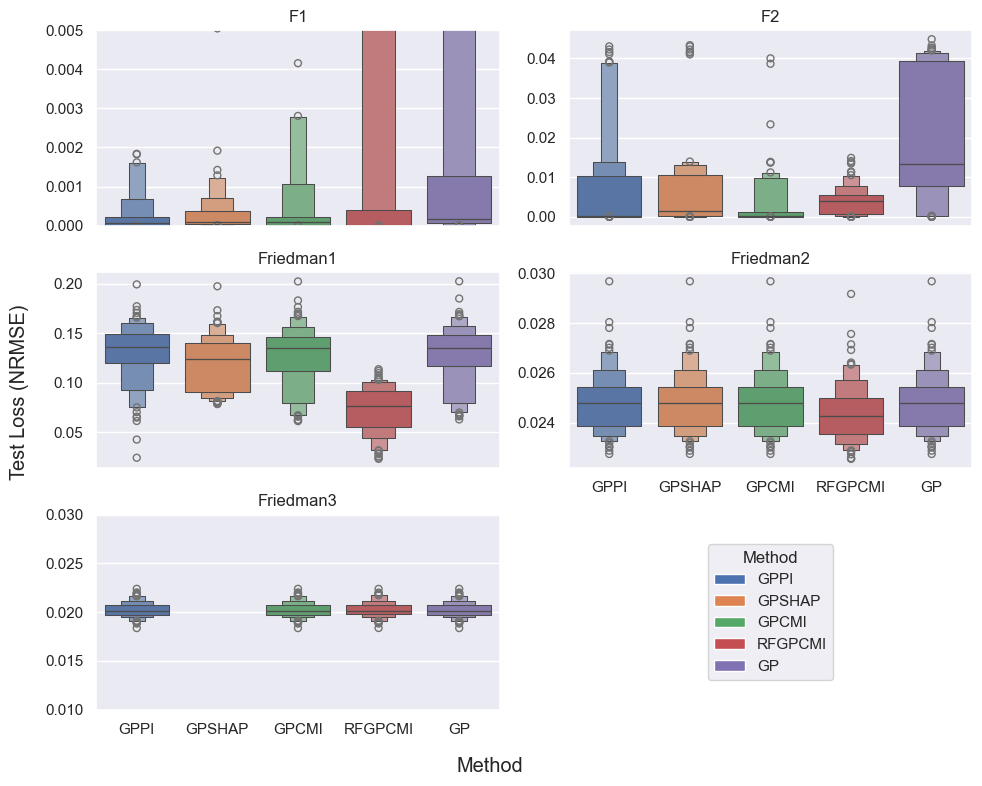

In [6]:
# Plotting test losses for each dataset and method at the last epoch
fig, axes = plot_results(
    results_df.groupby(level='run').last(), 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.boxenplot(data=data, ax=ax)
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[0].set_ylim(0, 0.005) # Set y-axis limits to zoom in on the boxenplots
axes[4].set_ylim(0.01, 0.03) # Set y-axis limits to zoom in on the boxenplots


# Create a custom legend with the same colors as the boxenplots
colors = sns.color_palette(n_colors=len(order['method']))
handles = [Patch(facecolor=c) for c in colors]
labels = order['method'].copy()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

In [7]:
# Calculate median test losses for each method and dataset at the last epoch
median_loss = results_df.groupby(level='run').last().median()
gp_median_loss = median_loss[:, "GP", :]

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

# Extract the median losses for the competitor methods
competitor_median_loss = median_loss.loc[:, methods, :]

# Calculate relative improvement of GP over competitors for each dataset and metric
relative_improvement = (gp_median_loss - competitor_median_loss) * 100 / gp_median_loss
relative_improvement_df = relative_improvement.to_frame().T

# Reorder the relative improvement DataFrame to match the desired column order for plotting
relative_improvement_df = relative_improvement_df.swaplevel('metric', 'method', axis=1)
relative_improvement_df = relative_improvement_df.reindex(columns=order['dataset'], level='dataset')
relative_improvement_df = relative_improvement_df.reindex(columns=methods, level='method')
relative_improvement_df = relative_improvement_df.reindex(columns=order['metric'], level='metric')
relative_improvement_df

dataset              F1                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0             67.902827         66.427378   56.363705        50.39442   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0               48.221107   48.117945       60.139743         63.604261   

dataset                              ...   Friedman3                  \
method                      RFGPCMI  ...        GPPI          GPSHAP   
metric  test_losses training_losses  ... test_losses training_losses   
0         53.306855       99.787335  ...         0.0     -517.806696   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0             -459.214172 -508.664167        0.163701          0.889797   

dataset                                                            
method                      RFGPCMI                                
metric  test_losses training_losses validation_losses test_losses  
0               0.0        -0.39171          0.889347    0.021266  

[1 rows x 60 columns]

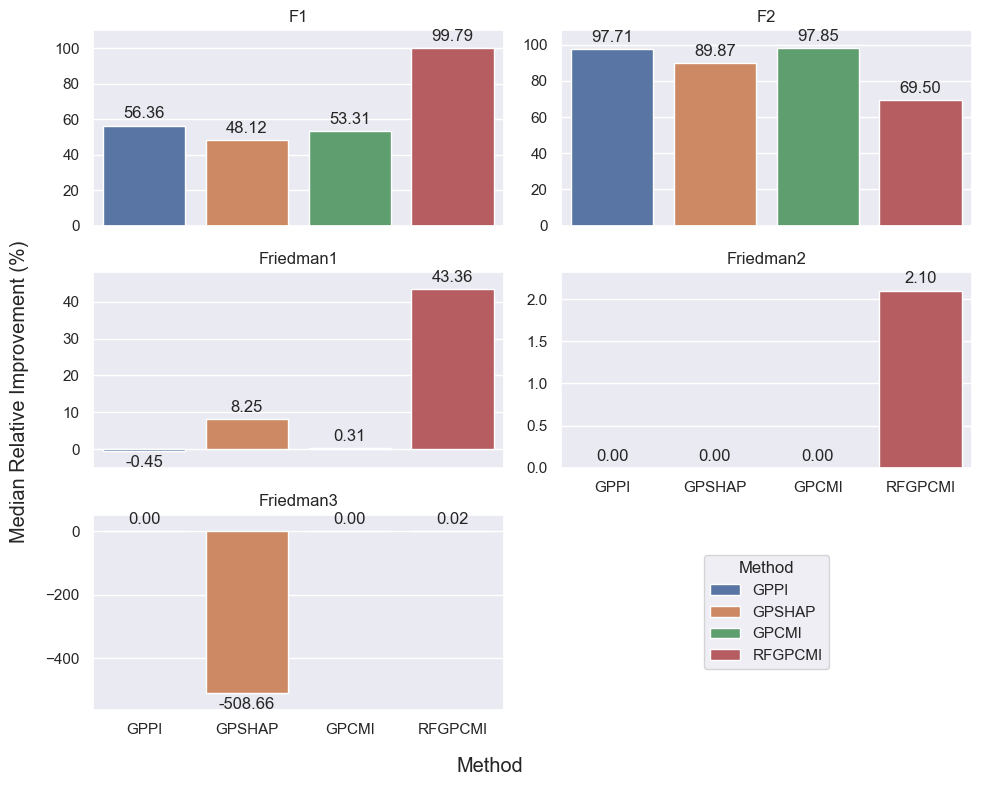

In [8]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_improvement_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Improvement (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

### Model Complexity

In [9]:
# Parse the true equations into SymPy expressions
true_equations_expr = {
    name: parse_expr(eq_str)
    for name, eq_str in true_equations_str.items()
}

# Calculate true tree sizes for each dataset using the true equations
true_sizes = {
    dataset: tree_size(expr)
    for dataset, expr in true_equations_expr.items()
}

In [10]:
# Calculate tree sizes for each run, method, and dataset in parallel using joblib
tree_sizes = {}
for ds in order['dataset']:
    tree_sizes[ds] = {}

    for m in order['method']:
        tree_sizes[ds][m] = Parallel(n_jobs=-1)(
            delayed(tree_size)(
                safe_simplify_timeout(get_final_expr(equations[ds], m, run), 10)
            ) for run in tqdm(range(num_runs), desc=f"Calculating tree sizes for {ds} - {m}")  
        )

Calculating tree sizes for Friedman3 - GP: 100%|██████████| 100/100 [00:00<00:00, 343.62it/s]


In [11]:
# Create a DataFrame to store tree sizes with MultiIndex columns for dataset and method
tree_sizes_column_order = pd.MultiIndex.from_product([order['dataset'], order['method']], names=['dataset', 'method'])

tree_sizes_df = pd.concat(
    {ds: pd.DataFrame(tree_sizes[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=tree_sizes_column_order)
tree_sizes_df.index.name = "run"
tree_sizes_df.tail(3)

dataset   F1                           F2                           ...  \
method  GPPI GPSHAP GPCMI RFGPCMI GP GPPI GPSHAP GPCMI RFGPCMI  GP  ...   
run                                                                 ...   
97         7      7     7      23  7   19      9    12      16   7  ...   
98         7      7     7      21  7    9      8    12      16   4  ...   
99         7      7     7      64  7   13      9    12      16  15  ...   

dataset Friedman2                         Friedman3                          
method       GPPI GPSHAP GPCMI RFGPCMI GP      GPPI GPSHAP GPCMI RFGPCMI GP  
run                                                                          
97              3      3     3       5  3         7      5     7       9  7  
98              3      3     3       5  3         7      4     7       9  7  
99              3      3     3       5  3         7      4     7       9  7  

[3 rows x 25 columns]

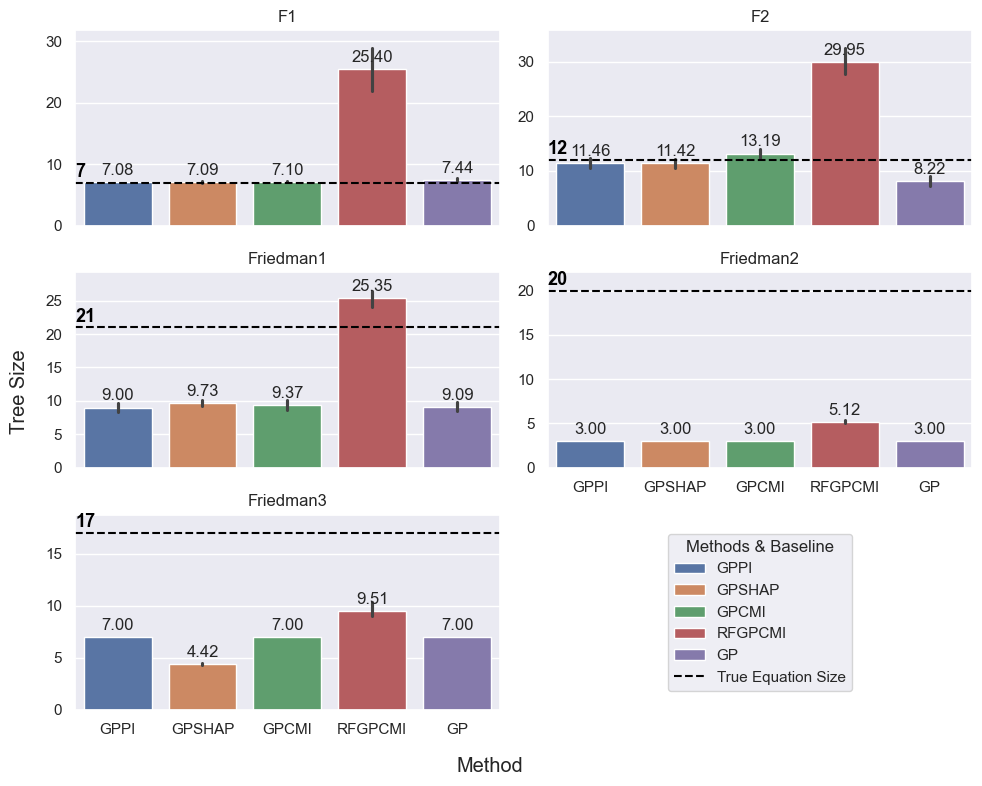

In [12]:
# Plotting tree sizes for each dataset and method at the last epoch
fig, axes = plot_results(
    tree_sizes_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Tree Size", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar, adjust y-axis limits, and add true value lines
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05
    text_offset_ratio = 0.03
    fontsize = 13

    dataset_name = ax.get_title()
    true_value = true_sizes[dataset_name]

    ax.axhline(
        y=true_value, 
        color='black', 
        linestyle='--', 
        linewidth=1.5,
        label='True Equation Size'
    )

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    ax.text(
        ax.get_xlim()[0], 
        true_value + text_offset_ratio * (top - bottom),
        f'{true_value}', 
        color='black',
        fontweight='bold',
        fontsize=fontsize,
    )

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handle, label = axes[4].get_legend_handles_labels()
handles = axes[4].containers + handle
labels = [text.get_text() for text in axes[4].get_xticklabels()] + label

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods & Baseline"
)
plt.show()

### Feature Selection Analysis

In [13]:
# Extract the true features used in each dataset's true equation
true_features_per_dataset = {
    dataset_name: {
        str(symbol) for symbol in equation.free_symbols
    } for dataset_name, equation in true_equations_expr.items()
}

In [14]:
# Calculate selection rates (TPR and FPR) for each method and dataset
selection_rates = {}

for dataset_name in order['dataset']:
    selection_rates[dataset_name] = {}

    for method_name in order['method']:
        selection_rates[dataset_name][method_name] = {
            "tpr": np.empty(num_runs),
            "fdr": np.empty(num_runs)
        }
        features_selected = features[dataset_name][method_name]

        for run in range(num_runs): 
            if method_name == "RFGPCMI":
                selected_features = set()

                for feature_list in features_selected[run]:
                    selected_features.update(feature_list)

            else:
                selected_features = set(features_selected[run])

            true_features = true_features_per_dataset[dataset_name]
            correctly_selected = selected_features & true_features
            falsely_selected = selected_features - true_features

            selection_rates[dataset_name][method_name]["tpr"][run] = len(correctly_selected) / len(true_features)
            selection_rates[dataset_name][method_name]["fdr"][run] = len(falsely_selected) / len(selected_features)

In [15]:
# Create a DataFrame to store selection rates with MultiIndex columns for dataset, method, and rate type (TPR/FDR)
selection_rate_types = ['tpr', 'fdr'] 
selection_rate_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method'], selection_rate_types], names=['dataset', 'method', 'rate_type']
)

selection_rate_df = pd.concat(
    {
        (ds, method): pd.DataFrame(selection_rates[ds][method])
        for ds in order['dataset']
        for method in order['method']
    },
    axis=1,
).reindex(columns=selection_rate_column_order)
selection_rate_df.index.name = "run"
selection_rate_df.tail(3)

dataset     F1                                                           ...  \
method    GPPI      GPSHAP      GPCMI       RFGPCMI        GP            ...   
rate_type  tpr  fdr    tpr  fdr   tpr   fdr     tpr  fdr  tpr       fdr  ...   
run                                                                      ...   
97         1.0  0.0    1.0  0.5   1.0  0.00     1.0  0.0  1.0  0.943396  ...   
98         1.0  0.0    1.0  0.5   1.0  0.25     1.0  0.0  1.0  0.943396  ...   
99         1.0  0.0    1.0  0.5   1.0  0.40     1.0  0.5  1.0  0.943396  ...   

dataset   Friedman3                                                     
method         GPPI      GPSHAP      GPCMI      RFGPCMI        GP       
rate_type       tpr  fdr    tpr  fdr   tpr  fdr     tpr  fdr  tpr  fdr  
run                                                                     
97             0.75  0.0    0.5  0.0  0.75  0.0    0.75  0.0  1.0  0.0  
98             0.75  0.0    0.5  0.0  0.75  0.0    0.75  0.0  1.0  0.0  
99             0.75  0.0    0.5  0.0  0.75  0.0    0.75  0.0  1.0  0.0  

[3 rows x 50 columns]

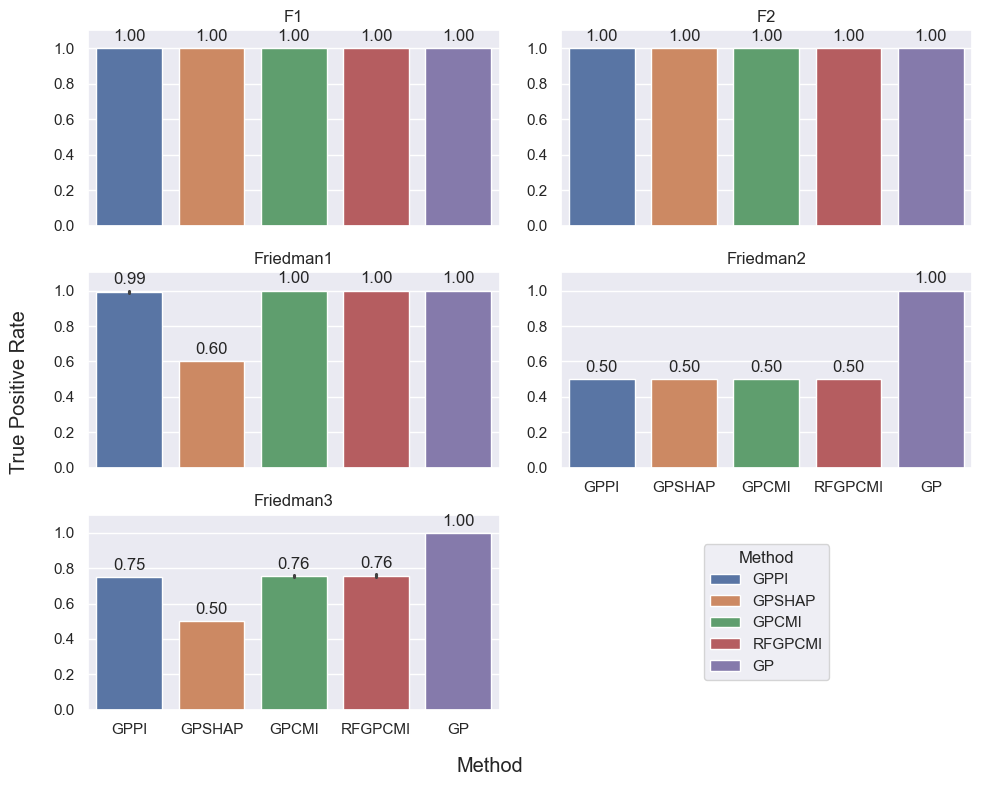

In [16]:
# Plotting true positive rates for each dataset and method at the last epoch
fig, axes = plot_results(
    selection_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="rate_type", 
    value_key="tpr",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("True Positive Rate", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

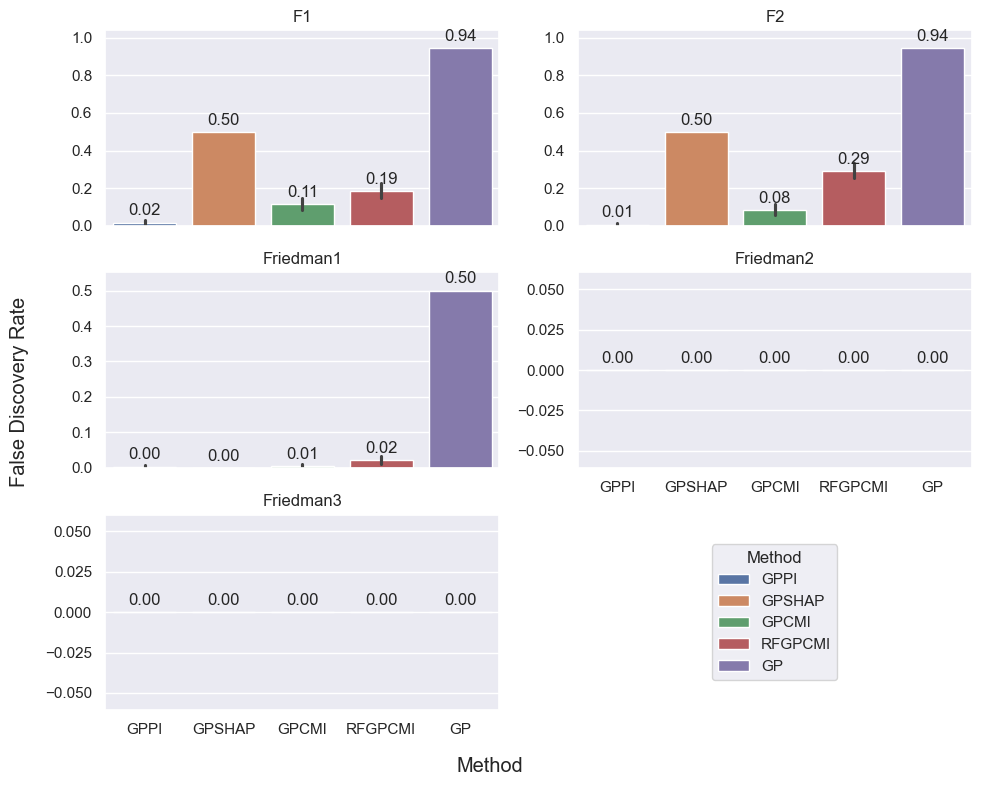

In [17]:
# Plotting false discovery rates for each dataset and method at the last epoch
fig, axes = plot_results(
    selection_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="rate_type", 
    value_key="fdr",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("False Discovery Rate", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

### Computational Efficiency

In [18]:
# Create a DataFrame to store execution times with MultiIndex columns for dataset and method
time_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method']], names=['dataset', "method"]
)

execution_time_df = pd.concat({ds: pd.DataFrame(execution_times[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=time_column_order)
execution_time_df.index.name = "run"
execution_time_df.tail(3)

dataset          F1                                                       F2  \
method         GPPI      GPSHAP      GPCMI    RFGPCMI         GP        GPPI   
run                                                                            
97       678.777365  690.168520  35.963639  54.710922  37.186884  503.791579   
98       325.560931  432.049777  35.529003  57.216654  41.019608  548.239259   
99       681.988584  727.554824  47.669574  56.724390  39.798209  470.084329   

dataset                                                 ...   Friedman2  \
method        GPSHAP      GPCMI     RFGPCMI         GP  ...        GPPI   
run                                                     ...               
97        936.449190  60.127984   93.643908  40.962508  ...  701.844501   
98       1193.430691  71.820931  107.878357  44.217799  ...  561.962278   
99       1197.210956  67.532704   96.977592  44.414566  ...  722.611283   

dataset                                                Friedman3              \
method       GPSHAP      GPCMI    RFGPCMI         GP        GPPI      GPSHAP   
run                                                                            
97       776.833253  78.683336  29.694647  81.119123  692.750748  799.240865   
98       779.196329  81.433774  29.989213  81.778267  734.755070  798.850504   
99       662.707166  86.850758  31.499946  83.699802  709.026977  849.895560   

dataset                                   
method       GPCMI    RFGPCMI         GP  
run                                       
97       96.382906  35.588989  79.771638  
98       95.647107  32.436715  79.777414  
99       96.511130  36.224690  79.026342  

[3 rows x 25 columns]

In [19]:
# Calculate median relative time for each method and dataset
median_exec_time = execution_time_df.median()
baseline_exec_time = median_exec_time[:, "GP"]

relative_time = median_exec_time / baseline_exec_time
relative_time_df = relative_time.to_frame().T

relative_time_df = relative_time_df.reindex(columns=order['dataset'], level='dataset')
relative_time_df = relative_time_df.reindex(columns=order['method'], level='method')
relative_time_df

dataset         F1                                            F2            \
method        GPPI     GPSHAP     GPCMI   RFGPCMI   GP      GPPI    GPSHAP   
0        16.955273  14.900046  1.026258  1.463833  1.0  11.78492  26.04631   

dataset                           ... Friedman2                                \
method      GPCMI   RFGPCMI   GP  ...      GPPI    GPSHAP     GPCMI   RFGPCMI   
0        1.685781  2.424154  1.0  ...  8.601223  8.742856  1.039301  0.381214   

dataset      Friedman3                                     
method    GP      GPPI    GPSHAP     GPCMI   RFGPCMI   GP  
0        1.0  8.642566  9.643819  1.182547  0.443943  1.0  

[1 rows x 25 columns]

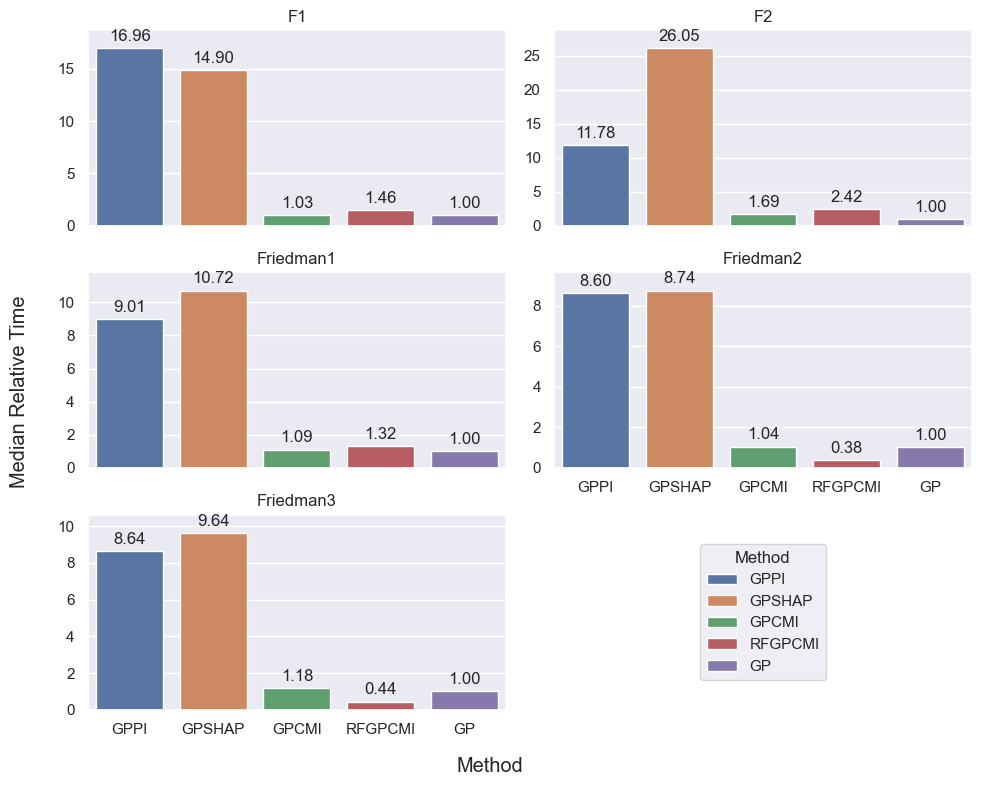

In [20]:
# Plotting relative time of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_time_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Median Relative Time", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()

In [21]:
# Calculate relative loss based on the median loss of GP
baseline_loss = median_loss[:, "GP", :]

relative_loss = median_loss / baseline_loss
relative_loss_df = relative_loss.to_frame().T

# Reorder the relative loss DataFrame to match the desired column order for plotting
relative_loss_df = relative_loss_df.reindex(columns=order['dataset'], level='dataset')
relative_loss_df = relative_loss_df.reindex(columns=order['method'], level='method')
relative_loss_df = relative_loss_df.reindex(columns=order['metric'], level='metric')
relative_loss_df

dataset              F1                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0              0.320972          0.335726    0.436363        0.496056   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                0.517789    0.518821        0.398603          0.363957   

dataset                              ...   Friedman3                  \
method                      RFGPCMI  ...      GPSHAP           GPCMI   
metric  test_losses training_losses  ... test_losses training_losses   
0          0.466931        0.002127  ...    6.086642        0.998363   

dataset                                                                  \
method                                        RFGPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                0.991102         1.0        1.003917          0.991107   

dataset                                                            
method                           GP                                
metric  test_losses training_losses validation_losses test_losses  
0          0.999787             1.0               1.0         1.0  

[1 rows x 75 columns]

In [22]:
# Calculate computational efficiency as the inverse of the product of median loss and relative time
computational_efficiency_df = 1 / (relative_loss_df * relative_time_df)

for level, cols in order.items():
    computational_efficiency_df = computational_efficiency_df.reindex(columns=cols, level=level)

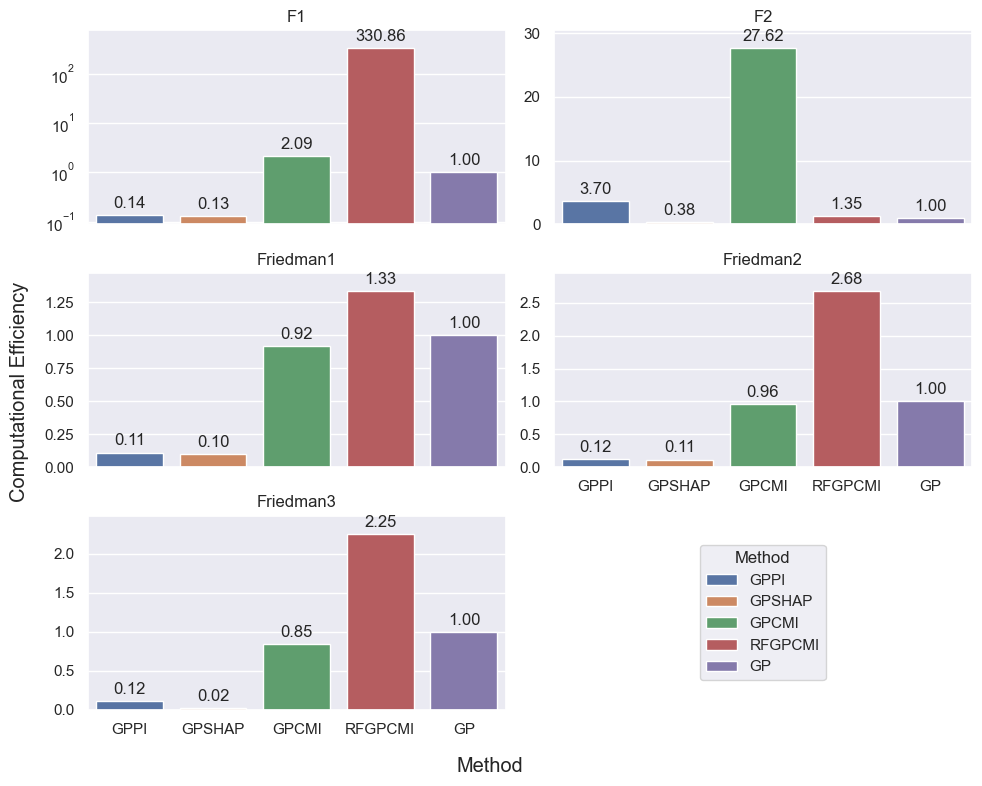

In [23]:
# Plotting the ratio of median test loss to median relative time for each dataset and method
fig, axes = plot_results(
    computational_efficiency_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Method", x=0.5, y=0.02)
fig.supylabel("Computational Efficiency", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    if (ax.get_ylim()[1] - ax.get_ylim()[0]) <= 1e2:
        bottom, top = ax.get_ylim()
        y_padding = margin_ratio * (top - bottom)
        new_top = top + y_padding

    else:
        ax.set_yscale('log')
        bottom, top = ax.get_ylim()
        y_padding = margin_ratio * (np.log10(top) - np.log10(bottom))
        new_top = top * (10 ** y_padding)

    ax.set_ylim(bottom, new_top)    

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=base_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Method"
)
plt.show()